# 09. Bayesian Causal Inference

Bayesian causal inference is not a different definition of causality. It is a probabilistic way to reason about causal estimands, uncertainty, prior information, heterogeneity, missing potential outcomes, and decisions.

The causal part still comes from design:

- What is the intervention?
- What is the estimand?
- Why are treatment groups exchangeable?
- What variables must be adjusted for?
- What assumptions identify the missing potential outcomes?

The Bayesian part gives a coherent way to express uncertainty after those design choices:

$$
p(\text{causal estimand} \mid \text{data}, \text{model}, \text{assumptions})
$$

This notebook builds Bayesian causal analyses from small pieces: Bayesian A/B testing, posterior treatment effects, Bayesian regression adjustment, prior sensitivity, hierarchical treatment effects, causal impact with counterfactual forecasting, and decision analysis.


## Learning Goals

By the end of this notebook, you should be able to:

- Explain how Bayesian inference fits into the potential outcomes framework.
- Compute posterior distributions for treatment effects in randomized experiments.
- Interpret posterior probabilities, credible intervals, and decision probabilities.
- Use Bayesian regression adjustment for causal effects under exchangeability assumptions.
- Explain why Bayesian modeling does not fix unmeasured confounding by itself.
- Use hierarchical shrinkage to stabilize segment-level treatment effects.
- Run prior sensitivity analysis for small experiments.
- Build a lightweight Bayesian causal-impact analysis using pre-period controls.
- Translate posterior causal uncertainty into expected business value and launch decisions.


## 1. Setup

We will use numpy, pandas, scipy, statsmodels, seaborn, matplotlib, and Graphviz. The examples use direct posterior simulation so the notebook remains portable for the website without heavyweight probabilistic programming.


In [1]:
# Import the analysis, modeling, and plotting tools used throughout this notebook.
import warnings
warnings.filterwarnings("ignore")

from graphviz import Digraph
from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from scipy.special import expit
import statsmodels.api as sm
import statsmodels.formula.api as smf

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


def summarize_draws(draws, name="estimand", reference=0):
    """Summarize the draws result.
    
    Inputs:
    - `draws`: number of posterior draws or array of posterior draws to summarize.
    - `name`: human-readable label for the posterior, policy, or display row.
    - `reference`: reference value shown as a vertical line, often the true or benchmark effect.
    Returns: a compact pandas summary of the effect, posterior, or policy calculation."""
    draws = np.asarray(draws, dtype=float)
    return pd.Series(
        {
            "estimand": name,
            "mean": draws.mean(),
            "median": np.median(draws),
            "sd": draws.std(ddof=1),
            "q025": np.quantile(draws, 0.025),
            "q975": np.quantile(draws, 0.975),
            f"Pr({name} > {reference})": np.mean(draws > reference),
        }
    )


def plot_posterior(draws, title, xlabel, reference=0, decision_threshold=None, figsize=(8, 4)):
    """Plot the posterior display.
    
    Inputs:
    - `draws`: number of posterior draws or array of posterior draws to summarize.
    - `title`: plot or graph title displayed above the figure.
    - `xlabel`: x-axis label used in the estimate plot.
    - `reference`: reference value shown as a vertical line, often the true or benchmark effect.
    - `decision_threshold`: minimum effect or value threshold marked on the posterior plot.
    - `figsize`: Matplotlib figure size passed to the plotting function.
    Returns: a Matplotlib figure or axes object that visualizes the causal estimates."""
    fig, ax = plt.subplots(figsize=figsize)
    sns.histplot(draws, bins=55, kde=True, color="#9ecae1", ax=ax)
    ax.axvline(reference, color="#444444", linestyle="--", linewidth=1, label=f"Reference = {reference:g}")
    if decision_threshold is not None:
        ax.axvline(decision_threshold, color="#de2d26", linestyle=":", linewidth=2, label=f"Decision threshold = {decision_threshold:g}")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Posterior draws")
    ax.legend()
    plt.tight_layout()
    return fig, ax


def plot_interval_table(table, title, xlabel, reference=0, figsize=(8.5, 4.5)):
    """Plot the interval table display.
    
    Inputs:
    - `table`: estimate table with columns such as estimate, standard error, and confidence limits.
    - `title`: plot or graph title displayed above the figure.
    - `xlabel`: x-axis label used in the estimate plot.
    - `reference`: reference value shown as a vertical line, often the true or benchmark effect.
    - `figsize`: Matplotlib figure size passed to the plotting function.
    Returns: a Matplotlib figure or axes object that visualizes the causal estimates."""
    plot_df = table.copy().sort_values("mean")
    fig, ax = plt.subplots(figsize=figsize)
    ax.errorbar(
        x=plot_df["mean"],
        y=plot_df.index,
        xerr=[
            plot_df["mean"] - plot_df["q025"],
            plot_df["q975"] - plot_df["mean"],
        ],
        fmt="o",
        color="#2b8cbe",
        ecolor="#a6bddb",
        elinewidth=3,
        capsize=4,
    )
    ax.axvline(reference, color="#444444", linestyle="--", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("")
    plt.tight_layout()
    return fig, ax


### Dataset and Experiment Setup

The notebook uses simulated experiments, observational confounding examples, segment-level effects, and counterfactual time series. The unit changes by section. Some sections use users in a randomized experiment, some use segments or markets, and some use a treated time series with control series. Treatments include product changes, interventions, and market-level launches. Outcomes include binary conversion, continuous value, segment response, and post-launch time-series behavior.

Synthetic data is used because Bayesian causal inference still needs causal identification. The notebook is not claiming that posterior modeling alone creates causal evidence. By generating the data, the examples can show posterior uncertainty, prior sensitivity, regression adjustment, unmeasured-confounding bias, hierarchical shrinkage, causal-impact style forecasting, and decision thresholds against known structure. This helps the reader separate two questions: what causal estimand is identified by the design, and how uncertainty about that estimand should be represented for decisions.


## 2. Bayesian Inference and Potential Outcomes

For each unit, the potential outcomes are:

$$
Y_i(1), \quad Y_i(0)
$$

The individual causal effect is:

$$
Y_i(1) - Y_i(0)
$$

but we observe only one potential outcome per unit:

$$
Y_i = A_i Y_i(1) + (1-A_i)Y_i(0)
$$

Bayesian causal inference treats missing potential outcomes and causal estimands as uncertain quantities. A posterior distribution for the average treatment effect might be written:

$$
p\left(ATE \mid Y^{obs}, A, X\right)
$$

where the identification assumptions still matter. Bayesian updating does not remove the need for exchangeability, positivity, consistency, and correct measurement.


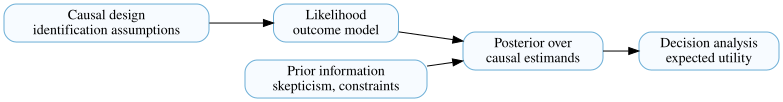

In [2]:
dot = Digraph("bayesian_causal_pipeline", graph_attr={"rankdir": "LR"})
dot.attr("node", shape="box", style="rounded,filled", fillcolor="#f7fbff", color="#6baed6")

dot.node("Design", "Causal design\nidentification assumptions")
dot.node("Prior", "Prior information\nskepticism, constraints")
dot.node("Likelihood", "Likelihood\noutcome model")
dot.node("Posterior", "Posterior over\ncausal estimands")
dot.node("Decision", "Decision analysis\nexpected utility")

dot.edge("Design", "Likelihood")
dot.edge("Prior", "Posterior")
dot.edge("Likelihood", "Posterior")
dot.edge("Posterior", "Decision")

dot


Rubin (1978) is a classic Bayesian treatment of causal effects and randomization. The modern Bayesian causal toolkit includes regression adjustment, Bayesian nonparametrics such as BART, Bayesian causal forests, hierarchical models, and Bayesian structural time-series models.


## 3. Bayesian A/B Test for a Binary Outcome

Start with a randomized product experiment.

Treatment is randomized, so the causal design is simple:

$$
A \perp (Y(1), Y(0))
$$

For binary conversion outcomes:

$$
Y_i(a) \sim Bernoulli(p_a)
$$

Use a beta prior:

$$
p_a \sim Beta(\alpha_a, \beta_a)
$$

The posterior is:

$$
p_a \mid data \sim Beta(\alpha_a + y_a,\ \beta_a + n_a - y_a)
$$

The treatment effect can be represented by posterior draws:

$$
\Delta = p_1 - p_0
$$


In [3]:
# Generate the teaching data and keep the causal quantities needed for diagnostics.
rng = np.random.default_rng(4909)
n_control = 5200
n_treated = 5100
true_p0 = 0.118
true_p1 = 0.129

y_control = rng.binomial(n_control, true_p0)
y_treated = rng.binomial(n_treated, true_p1)

alpha0, beta0 = 1, 1
posterior_control = (alpha0 + y_control, beta0 + n_control - y_control)
posterior_treated = (alpha0 + y_treated, beta0 + n_treated - y_treated)

draws = 80_000
p0_draws = rng.beta(*posterior_control, size=draws)
p1_draws = rng.beta(*posterior_treated, size=draws)
lift_draws = p1_draws - p0_draws
relative_lift_draws = lift_draws / p0_draws

ab_summary = pd.DataFrame(
    [
        summarize_draws(p0_draws, "p_control"),
        summarize_draws(p1_draws, "p_treated"),
        summarize_draws(lift_draws, "absolute_lift"),
        summarize_draws(relative_lift_draws, "relative_lift"),
    ]
)

experiment_counts = pd.DataFrame(
    {
        "arm": ["Control", "Treatment"],
        "n": [n_control, n_treated],
        "conversions": [y_control, y_treated],
        "observed_rate": [y_control / n_control, y_treated / n_treated],
    }
)

experiment_counts, ab_summary


(         arm     n  conversions  observed_rate
 0    Control  5200          593         0.1140
 1  Treatment  5100          635         0.1245,
         estimand   mean  median     sd    q025   q975  Pr(p_control > 0)  \
 0      p_control 0.1142  0.1141 0.0044  0.1057 0.1230             1.0000   
 1      p_treated 0.1247  0.1246 0.0046  0.1157 0.1338                NaN   
 2  absolute_lift 0.0105  0.0105 0.0064 -0.0021 0.0229                NaN   
 3  relative_lift 0.0934  0.0918 0.0585 -0.0175 0.2118                NaN   
 
    Pr(p_treated > 0)  Pr(absolute_lift > 0)  Pr(relative_lift > 0)  
 0                NaN                    NaN                    NaN  
 1             1.0000                    NaN                    NaN  
 2                NaN                 0.9487                    NaN  
 3                NaN                    NaN                 0.9487  )

Here the numbers should guide the next practical choice. Bayesian readouts should show effect size, uncertainty, and what the posterior implies for the action.

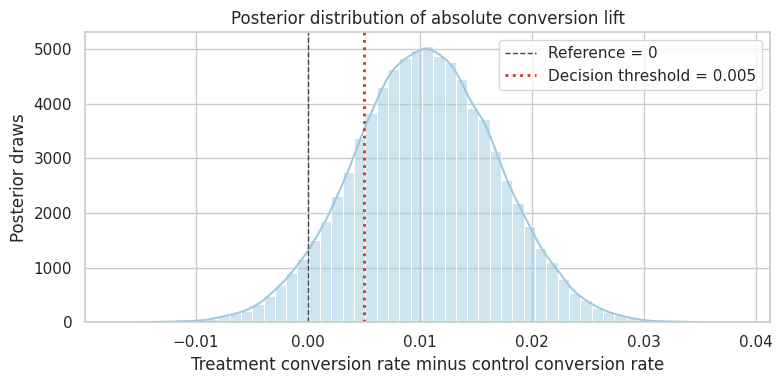

Pr(lift > 0)                       0.9487
Pr(lift > 0.5 percentage points)   0.8062
Pr(relative lift > 5%)             0.7682
dtype: float64

In [4]:
plot_posterior(
    lift_draws,
    title="Posterior distribution of absolute conversion lift",
    xlabel="Treatment conversion rate minus control conversion rate",
    reference=0,
    decision_threshold=0.005,
)
plt.show()

pd.Series(
    {
        "Pr(lift > 0)": np.mean(lift_draws > 0),
        "Pr(lift > 0.5 percentage points)": np.mean(lift_draws > 0.005),
        "Pr(relative lift > 5%)": np.mean(relative_lift_draws > 0.05),
    }
)


### Interpretation

The posterior answers decision-oriented questions directly:

- What is the probability the lift is positive?
- What is the probability it exceeds a practical threshold?
- How large is the downside risk?

This is often easier to communicate than only reporting a p-value. But the result is still conditional on the causal design and the model.


## 4. Prior Sensitivity in Small Experiments

With large experiments, weak priors usually have little impact. With small experiments, priors matter.

Let us compare:

- a weak uniform prior,
- a mildly skeptical prior centered around a 10% conversion rate,
- an optimistic prior expecting the treatment to improve conversion.


In [5]:
# Generate the teaching data and keep the causal quantities needed for diagnostics.
rng = np.random.default_rng(4910)
small_n_control = 180
small_n_treated = 175
small_y_control = rng.binomial(small_n_control, 0.10)
small_y_treated = rng.binomial(small_n_treated, 0.125)

prior_specs = {
    "Weak uniform": {"control": (1, 1), "treated": (1, 1)},
    "Skeptical around 10%": {"control": (20, 180), "treated": (20, 180)},
    "Optimistic treatment prior": {"control": (20, 180), "treated": (28, 172)},
}

prior_rows = []
prior_draws = {}
for prior_name, spec in prior_specs.items():
    c_post = (
        spec["control"][0] + small_y_control,
        spec["control"][1] + small_n_control - small_y_control,
    )
    t_post = (
        spec["treated"][0] + small_y_treated,
        spec["treated"][1] + small_n_treated - small_y_treated,
    )
    c_draw = rng.beta(*c_post, size=60_000)
    t_draw = rng.beta(*t_post, size=60_000)
    effect = t_draw - c_draw
    prior_draws[prior_name] = effect
    row = summarize_draws(effect, "lift")
    row["prior"] = prior_name
    prior_rows.append(row)

prior_sensitivity = pd.DataFrame(prior_rows).set_index("prior")
pd.Series(
    {
        "small_control_conversions": small_y_control,
        "small_treated_conversions": small_y_treated,
        "small_control_rate": small_y_control / small_n_control,
        "small_treated_rate": small_y_treated / small_n_treated,
    }
), prior_sensitivity


(small_control_conversions   22.0000
 small_treated_conversions   23.0000
 small_control_rate           0.1222
 small_treated_rate           0.1314
 dtype: float64,
                            estimand   mean  median     sd    q025   q975  \
 prior                                                                      
 Weak uniform                   lift 0.0092  0.0093 0.0356 -0.0614 0.0791   
 Skeptical around 10%           lift 0.0041  0.0042 0.0229 -0.0407 0.0490   
 Optimistic treatment prior     lift 0.0254  0.0255 0.0239 -0.0213 0.0723   
 
                             Pr(lift > 0)  
 prior                                     
 Weak uniform                      0.6035  
 Skeptical around 10%              0.5721  
 Optimistic treatment prior        0.8560  )

The practical takeaway is simple. The posterior is most useful when it connects uncertainty directly to a decision.

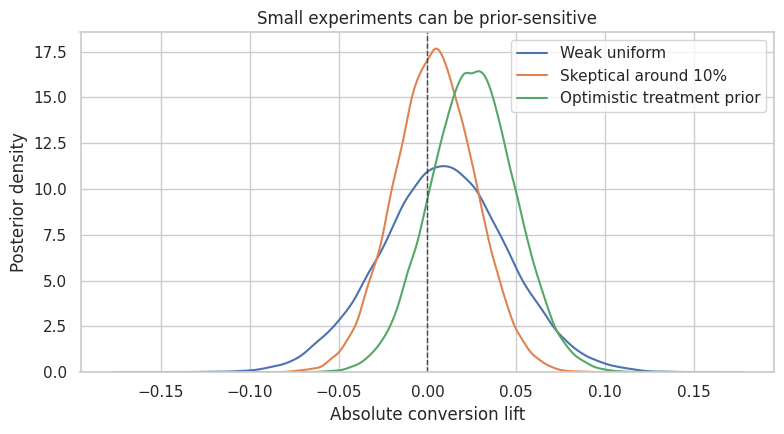

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for prior_name, effect in prior_draws.items():
    sns.kdeplot(effect, ax=ax, label=prior_name)
ax.axvline(0, color="#444444", linestyle="--", linewidth=1)
ax.set_title("Small experiments can be prior-sensitive")
ax.set_xlabel("Absolute conversion lift")
ax.set_ylabel("Posterior density")
ax.legend()
plt.tight_layout()
plt.show()


### Practical Rule

Prior sensitivity is not a weakness to hide. It is information.

If a decision changes depending on a plausible prior, say that the experiment is not decisive. The professional response is usually one of:

- collect more data,
- use stronger historical evidence,
- narrow the decision threshold,
- make a reversible low-risk decision,
- explicitly price the uncertainty.


## 5. Bayesian Continuous-Outcome Experiment

For a continuous outcome, we can model each arm with a normal likelihood:

$$
Y_i(a) \sim Normal(\mu_a, \sigma_a^2)
$$

Using a weak normal-inverse-gamma prior, we can sample from the posterior of each arm's mean and form:

$$
\Delta = \mu_1 - \mu_0
$$


In [7]:
# Generate the teaching data and keep the causal quantities needed for diagnostics.
def normal_inverse_gamma_posterior_draws(y, draws=50_000, mu0=0, kappa0=1e-4, alpha0=1e-3, beta0=1e-3, rng=None):
    """Draw posterior means and variances for a normal outcome model.
    
    Inputs:
    - `y`: continuous outcome observations from one experimental arm.
    - `draws`: number of posterior draws or array of posterior draws to summarize.
    - `mu0`: prior mean for the normal outcome mean.
    - `kappa0`: prior effective sample size for the normal outcome mean.
    - `alpha0`: prior shape parameter for the inverse-gamma variance prior.
    - `beta0`: prior scale parameter for the inverse-gamma variance prior.
    - `rng`: NumPy random generator used to make simulation draws reproducible within a larger workflow.
    Returns: posterior draws for the arm mean and variance under a normal-inverse-gamma prior."""
    if rng is None:
        rng = np.random.default_rng()
    y = np.asarray(y, dtype=float)
    n = len(y)
    ybar = y.mean()
    ss = np.sum((y - ybar) ** 2)
    kappa_n = kappa0 + n
    mu_n = (kappa0 * mu0 + n * ybar) / kappa_n
    alpha_n = alpha0 + n / 2
    beta_n = beta0 + 0.5 * ss + (kappa0 * n * (ybar - mu0) ** 2) / (2 * kappa_n)
    sigma2 = stats.invgamma.rvs(a=alpha_n, scale=beta_n, size=draws, random_state=rng)
    mu = rng.normal(mu_n, np.sqrt(sigma2 / kappa_n))
    return mu, sigma2


rng = np.random.default_rng(4911)
n = 1400
df_exp = pd.DataFrame({"A": rng.binomial(1, 0.5, size=n)})
df_exp["pre_value"] = rng.normal(0, 1, size=n)
true_continuous_effect = 1.25
df_exp["Y"] = (
    20
    + true_continuous_effect * df_exp["A"]
    + 2.5 * df_exp["pre_value"]
    + rng.normal(0, 6, size=n)
)

mu0_draw, _ = normal_inverse_gamma_posterior_draws(df_exp.loc[df_exp["A"] == 0, "Y"], rng=rng)
mu1_draw, _ = normal_inverse_gamma_posterior_draws(df_exp.loc[df_exp["A"] == 1, "Y"], rng=rng)
continuous_effect_draws = mu1_draw - mu0_draw

continuous_summary = summarize_draws(continuous_effect_draws, "mean_difference")
continuous_summary


estimand                   mean_difference
mean                                1.3457
median                              1.3454
sd                                  0.3393
q025                                0.6827
q975                                2.0118
Pr(mean_difference > 0)             0.9999
dtype: object

The result is useful when it changes what we audit, estimate, or decide. Priors and likelihoods are part of the decision analysis, so sensitivity should remain visible.

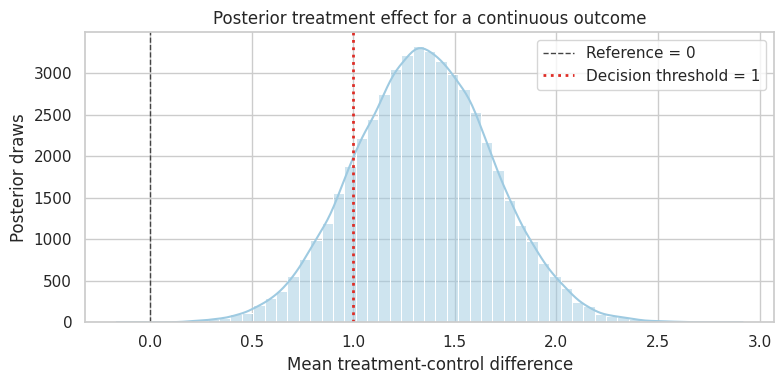

In [8]:
plot_posterior(
    continuous_effect_draws,
    title="Posterior treatment effect for a continuous outcome",
    xlabel="Mean treatment-control difference",
    reference=0,
    decision_threshold=1.0,
)
plt.show()


This posterior is based on a randomized experiment. We do not need to model treatment assignment to identify the effect. The Bayesian model summarizes uncertainty about the arm means and their difference.


## 6. Bayesian Regression Adjustment

Regression adjustment can improve precision and estimate conditional effects.

Assume:

$$
Y_i = X_i^\top\beta + \epsilon_i
$$

with:

$$
\epsilon_i \sim Normal(0, \sigma^2)
$$

and a conjugate prior:

$$
\beta \mid \sigma^2 \sim Normal(\beta_0, \sigma^2 V_0)
$$

$$
\sigma^2 \sim InvGamma(a_0, b_0)
$$

The treatment coefficient posterior gives a regression-adjusted causal effect in a randomized experiment, assuming the model is adequate for the adjustment target.


In [9]:
# Generate the teaching data and keep the causal quantities needed for diagnostics.
def bayesian_linear_regression_draws(X, y, draws=50_000, beta0=None, V0_scale=1e6, a0=1e-3, b0=1e-3, rng=None):
    """Draw posterior regression coefficients for Bayesian adjustment.
    
    Inputs:
    - `X`: feature matrix used for prediction or Bayesian regression.
    - `y`: continuous outcome vector for Bayesian regression.
    - `draws`: number of posterior draws or array of posterior draws to summarize.
    - `beta0`: prior scale parameter for the inverse-gamma variance prior.
    - `V0_scale`: prior variance scale for Bayesian regression coefficients.
    - `a0`: prior shape parameter for the Bayesian regression variance prior.
    - `b0`: prior scale parameter for the Bayesian regression variance prior.
    - `rng`: NumPy random generator used to make simulation draws reproducible within a larger workflow.
    Returns: posterior draws of regression coefficients and residual variance."""
    if rng is None:
        rng = np.random.default_rng()
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    n, p = X.shape
    if beta0 is None:
        beta0 = np.zeros(p)
    beta0 = np.asarray(beta0, dtype=float)
    V0_inv = np.eye(p) / V0_scale
    Vn = np.linalg.inv(V0_inv + X.T @ X)
    beta_n = Vn @ (V0_inv @ beta0 + X.T @ y)
    a_n = a0 + n / 2
    residual_part = y.T @ y + beta0.T @ V0_inv @ beta0 - beta_n.T @ np.linalg.inv(Vn) @ beta_n
    b_n = b0 + 0.5 * residual_part
    sigma2_draws = stats.invgamma.rvs(a=a_n, scale=b_n, size=draws, random_state=rng)
    beta_draws = np.empty((draws, p))
    chol = np.linalg.cholesky(Vn)
    z = rng.normal(size=(draws, p))
    for i in range(draws):
        beta_draws[i] = beta_n + np.sqrt(sigma2_draws[i]) * (chol @ z[i])
    return beta_draws, sigma2_draws


X = sm.add_constant(df_exp[["A", "pre_value"]]).to_numpy()
y = df_exp["Y"].to_numpy()
beta_draws, sigma2_draws = bayesian_linear_regression_draws(X, y, draws=50_000, rng=rng)
regression_effect_draws = beta_draws[:, 1]

adjusted_summary = pd.DataFrame(
    [
        summarize_draws(continuous_effect_draws, "unadjusted_mean_difference"),
        summarize_draws(regression_effect_draws, "regression_adjusted_effect"),
    ]
).set_index("estimand")

adjusted_summary


,mean,median,sd,q025,q975,Pr(unadjusted_mean_difference > 0),Pr(regression_adjusted_effect > 0)
estimand,,,,,,,
unadjusted_mean_difference,1.3457,1.3454,0.3393,0.6827,2.0118,0.9999,NaN
regression_adjusted_effect,1.0392,1.0407,0.3125,0.4243,1.6511,NaN,0.9995


This checkpoint is about credibility and estimation together. Bayesian readouts should show effect size, uncertainty, and what the posterior implies for the action.

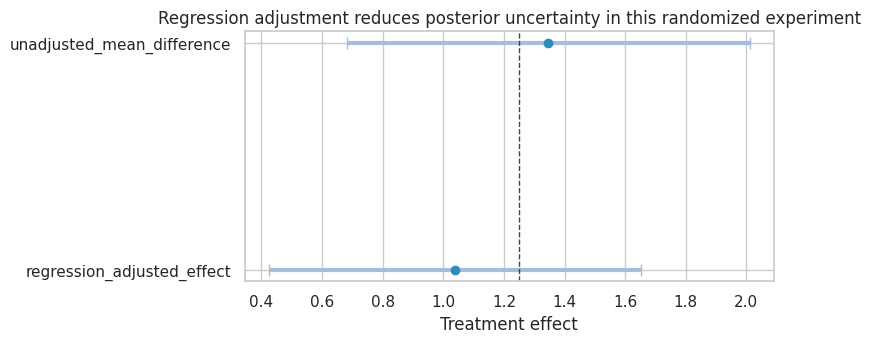

In [10]:
plot_interval_table(
    adjusted_summary,
    title="Regression adjustment reduces posterior uncertainty in this randomized experiment",
    xlabel="Treatment effect",
    reference=true_continuous_effect,
    figsize=(8, 3.6),
)
plt.show()


The regression-adjusted posterior is narrower because `pre_value` is strongly predictive of the outcome. Randomization identifies the effect; regression uses baseline information to improve precision.

priors and likelihoods combine into a posterior decision analysis. The result should show both effect size and uncertainty about the action.

## 7. Bayesian Modeling Does Not Fix Unmeasured Confounding

Bayesian regression can adjust for measured covariates. Omitted variables remain outside the model.

Now simulate observational treatment assignment:

$$
P(A=1 \mid X, U)
$$

where $U$ is unobserved in the analyst's dataset and affects $Y$.


In [11]:
# Generate the teaching data and keep the causal quantities needed for diagnostics.
rng = np.random.default_rng(4912)
n = 4500
obs = pd.DataFrame(
    {
        "X": rng.normal(size=n),
        "U": rng.normal(size=n),
    }
)
true_obs_effect = 1.0
obs["A"] = rng.binomial(1, expit(-0.2 + 1.0 * obs["X"] + 1.1 * obs["U"]), size=n)
obs["Y"] = 5 + true_obs_effect * obs["A"] + 1.4 * obs["X"] + 2.0 * obs["U"] + rng.normal(0, 1.4, size=n)

def posterior_treatment_coef(data, predictors, draws=40_000):
    """Sample the posterior treatment coefficient from a Bayesian regression adjustment.
    
    Inputs:
    - `data`: pandas DataFrame passed into the estimator, usually containing treatment, outcome, and covariate columns.
    - `predictors`: list of regression predictors included in the Bayesian adjustment model.
    - `draws`: number of posterior draws or array of posterior draws to summarize.
    Returns: posterior draws for the treatment-effect coefficient under the selected predictor set."""
    Xmat = sm.add_constant(data[predictors]).to_numpy()
    beta, _ = bayesian_linear_regression_draws(Xmat, data["Y"].to_numpy(), draws=draws, rng=rng)
    treatment_index = ["const"] + predictors
    return beta[:, treatment_index.index("A")]


unadjusted_draws = posterior_treatment_coef(obs, ["A"])
adjust_x_draws = posterior_treatment_coef(obs, ["A", "X"])
oracle_draws = posterior_treatment_coef(obs, ["A", "X", "U"])

confounding_summary = pd.DataFrame(
    [
        summarize_draws(unadjusted_draws, "Unadjusted"),
        summarize_draws(adjust_x_draws, "Adjust for observed X"),
        summarize_draws(oracle_draws, "Oracle adjust for X and U"),
    ]
).set_index("estimand")

confounding_summary


,mean,median,sd,q025,q975,Pr(Unadjusted > 0),Pr(Adjust for observed X > 0),Pr(Oracle adjust for X and U > 0)
estimand,,,,,,,,
Unadjusted,3.5657,3.5656,0.0752,3.4178,3.7118,1.0000,NaN,NaN
Adjust for observed X,2.7790,2.7790,0.0730,2.6366,2.9217,NaN,1.0000,NaN
Oracle adjust for X and U,0.9355,0.9353,0.0491,0.8396,1.0315,NaN,NaN,1.0000


The point is to connect the number to the decision it supports. The posterior is most useful when it connects uncertainty directly to a decision.

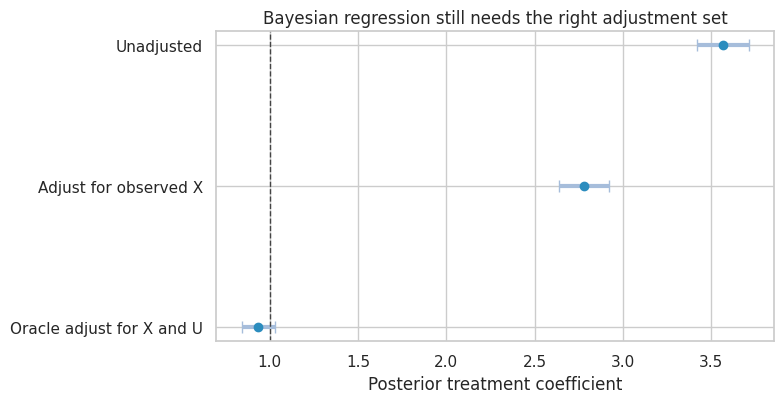

In [12]:
plot_interval_table(
    confounding_summary,
    title="Bayesian regression still needs the right adjustment set",
    xlabel="Posterior treatment coefficient",
    reference=true_obs_effect,
    figsize=(8, 4.2),
)
plt.show()


### Interpretation

The posterior intervals can be narrow and still centered on the wrong estimand. This is an important distinction:

- Bayesian inference quantifies uncertainty under the model.
- Causal identification decides whether the model targets the causal estimand.

Unmeasured confounding is not solved by adding a prior to an otherwise misspecified causal model.


## 8. Prior Over Bias: Sensitivity Analysis

One Bayesian way to handle unmeasured confounding is to place a prior over the bias.

Suppose the adjusted estimate is:

$$
\widehat{\tau}_{obs}
$$

but we believe unmeasured confounding may bias it upward by $B$:

$$
\tau = \widehat{\tau}_{obs} - B
$$

We can assign a prior to $B$ and propagate that uncertainty.


In [13]:
rng = np.random.default_rng(4913)
observed_effect_draws = adjust_x_draws

bias_scenarios = {
    "No extra confounding": rng.normal(0.0, 0.05, size=len(observed_effect_draws)),
    "Moderate upward bias": rng.normal(0.6, 0.25, size=len(observed_effect_draws)),
    "Large uncertain upward bias": rng.normal(1.1, 0.50, size=len(observed_effect_draws)),
}

bias_rows = []
bias_adjusted_draws = {}
for scenario, bias_draw in bias_scenarios.items():
    adjusted = observed_effect_draws - bias_draw
    bias_adjusted_draws[scenario] = adjusted
    row = summarize_draws(adjusted, scenario)
    bias_rows.append(row)

bias_sensitivity = pd.DataFrame(bias_rows).set_index("estimand")
bias_sensitivity


,mean,median,sd,q025,q975,Pr(No extra confounding > 0),Pr(Moderate upward bias > 0),Pr(Large uncertain upward bias > 0)
estimand,,,,,,,,
No extra confounding,2.7786,2.7786,0.0887,2.6064,2.9528,1.0000,NaN,NaN
Moderate upward bias,2.1776,2.1769,0.2622,1.6675,2.6924,NaN,1.0000,NaN
Large uncertain upward bias,1.6805,1.6826,0.5068,0.6717,2.6694,NaN,NaN,0.9996


Here the example becomes operational. Priors and likelihoods are part of the decision analysis, so sensitivity should remain visible.

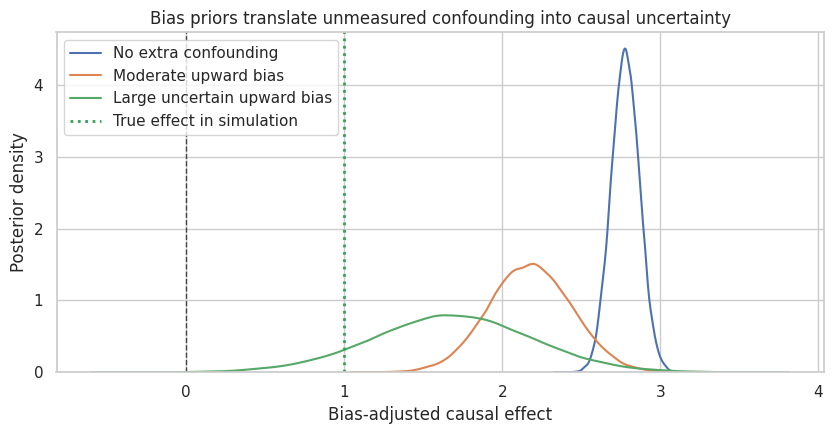

In [14]:
fig, ax = plt.subplots(figsize=(8.5, 4.5))
for scenario, draws_ in bias_adjusted_draws.items():
    sns.kdeplot(draws_, ax=ax, label=scenario)
ax.axvline(0, color="#444444", linestyle="--", linewidth=1)
ax.axvline(true_obs_effect, color="#31a354", linestyle=":", linewidth=2, label="True effect in simulation")
ax.set_title("Bias priors translate unmeasured confounding into causal uncertainty")
ax.set_xlabel("Bias-adjusted causal effect")
ax.set_ylabel("Posterior density")
ax.legend()
plt.tight_layout()
plt.show()


This approach is honest because it separates two uncertainties:

1. posterior uncertainty from the fitted outcome model,
2. causal uncertainty from unmeasured confounding.

The second uncertainty is not learned from the observed outcome regression alone. It comes from external knowledge, design judgment, negative controls, validation data, or sensitivity assumptions.


## 9. Hierarchical Treatment Effects Across Segments

Industry teams often want treatment effects by segment:

- region,
- customer tier,
- acquisition channel,
- product category,
- sales team,
- hospital,
- school.

Segment estimates are noisy when some segments are small. Hierarchical Bayesian models partially pool segment effects:

$$
\widehat{\tau}_j \sim Normal(\tau_j, s_j^2)
$$

$$
\tau_j \sim Normal(\mu, \omega^2)
$$

The posterior mean for segment $j$ is a precision-weighted average of the noisy segment estimate and the overall mean.


In [15]:
# Generate the teaching data and keep the causal quantities needed for diagnostics.
rng = np.random.default_rng(4914)
n_segments = 18
segment_sizes = rng.integers(80, 700, size=n_segments)
true_mu = 1.2
true_omega = 0.75

segment_rows = []
for j, size in enumerate(segment_sizes):
    true_tau_j = rng.normal(true_mu, true_omega)
    A = rng.binomial(1, 0.5, size=size)
    baseline = rng.normal(0, 1, size=size)
    Y = 10 + true_tau_j * A + 1.5 * baseline + rng.normal(0, 3.0, size=size)
    tmp = pd.DataFrame({"segment": f"S{j+1:02d}", "A": A, "baseline": baseline, "Y": Y, "true_tau": true_tau_j})
    segment_rows.append(tmp)

seg_df = pd.concat(segment_rows, ignore_index=True)

raw_rows = []
for segment, part in seg_df.groupby("segment"):
    model = smf.ols("Y ~ A + baseline", data=part).fit()
    raw_rows.append(
        {
            "segment": segment,
            "n": len(part),
            "raw_estimate": model.params["A"],
            "raw_se": model.bse["A"],
            "true_tau": part["true_tau"].iloc[0],
        }
    )

seg_est = pd.DataFrame(raw_rows)
mu_hat = np.average(seg_est["raw_estimate"], weights=1 / seg_est["raw_se"] ** 2)
between_var_hat = max(
    0.05,
    np.var(seg_est["raw_estimate"], ddof=1) - np.mean(seg_est["raw_se"] ** 2),
)
omega_hat = np.sqrt(between_var_hat)

prior_precision = 1 / omega_hat**2
data_precision = 1 / seg_est["raw_se"] ** 2
seg_est["shrunk_estimate"] = (
    data_precision * seg_est["raw_estimate"] + prior_precision * mu_hat
) / (data_precision + prior_precision)
seg_est["shrinkage_weight_on_raw"] = data_precision / (data_precision + prior_precision)

seg_est.sort_values("n").head(8), pd.Series({"overall_mu_hat": mu_hat, "omega_hat": omega_hat})


(   segment    n  raw_estimate  raw_se  true_tau  shrunk_estimate  \
 16     S17  120        1.6314  0.5140    1.4138           1.4284   
 15     S16  125        0.5686  0.5014    0.0904           0.7804   
 11     S12  241        1.6945  0.3672    1.0353           1.5502   
 10     S11  272        0.8079  0.3668    1.4261           0.8860   
 6      S07  288       -0.3294  0.3796    0.0723           0.0528   
 13     S14  362        1.0500  0.3185    0.7231           1.0640   
 14     S15  372        2.1028  0.2928    2.0549           1.9301   
 2      S03  377        1.4725  0.3064    0.9251           1.4057   
 
     shrinkage_weight_on_raw  
 16                   0.6036  
 15                   0.6154  
 11                   0.7490  
 10                   0.7494  
 6                    0.7362  
 13                   0.7986  
 14                   0.8243  
 2                    0.8108  ,
 overall_mu_hat   1.1195
 omega_hat        0.6343
 dtype: float64)

This output should make the next modeling choice easier to defend. Bayesian readouts should show effect size, uncertainty, and what the posterior implies for the action.

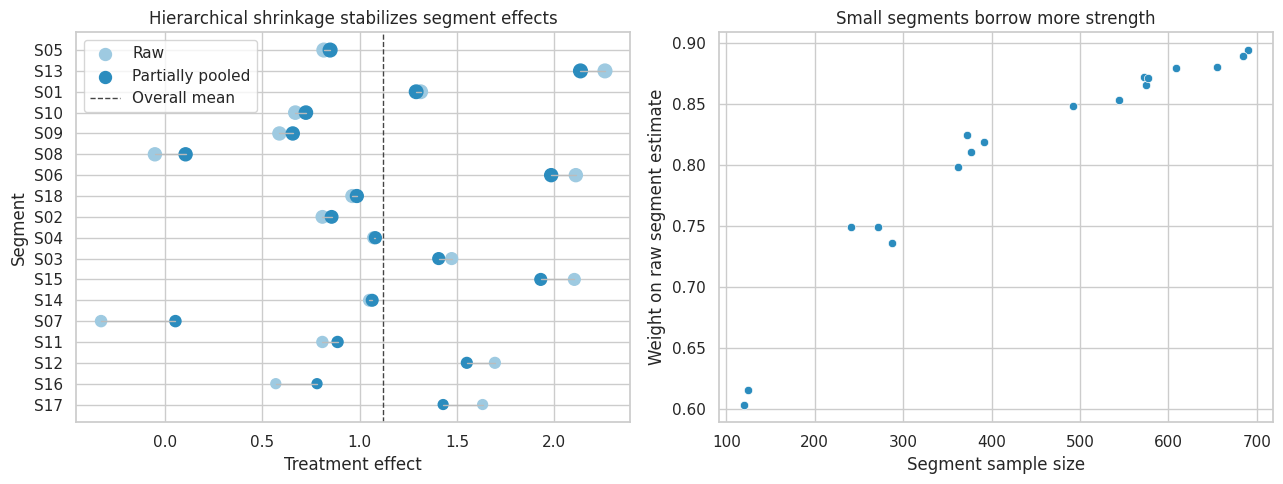

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

plot_df = seg_est.sort_values("n")
axes[0].scatter(plot_df["raw_estimate"], plot_df["segment"], s=40 + plot_df["n"] / 12, label="Raw", color="#9ecae1")
axes[0].scatter(plot_df["shrunk_estimate"], plot_df["segment"], s=40 + plot_df["n"] / 12, label="Partially pooled", color="#2b8cbe")
for _, row in plot_df.iterrows():
    axes[0].plot([row["raw_estimate"], row["shrunk_estimate"]], [row["segment"], row["segment"]], color="#bbbbbb", linewidth=1)
axes[0].axvline(mu_hat, color="#444444", linestyle="--", linewidth=1, label="Overall mean")
axes[0].set_title("Hierarchical shrinkage stabilizes segment effects")
axes[0].set_xlabel("Treatment effect")
axes[0].set_ylabel("Segment")
axes[0].legend()

sns.scatterplot(data=seg_est, x="n", y="shrinkage_weight_on_raw", ax=axes[1], color="#2b8cbe")
axes[1].set_title("Small segments borrow more strength")
axes[1].set_xlabel("Segment sample size")
axes[1].set_ylabel("Weight on raw segment estimate")

plt.tight_layout()
plt.show()


### Interpretation

Small, noisy segment estimates are pulled more strongly toward the overall mean. Large segments keep more of their own signal.

This is one reason Bayesian hierarchical models are common in applied causal work: they allow heterogeneous effects without treating every tiny subgroup estimate as equally reliable.


## 10. Bayesian Causal Impact with Counterfactual Forecasting

For market-level interventions, we may have one treated time series and one or more control series. A Bayesian structural time-series model predicts the counterfactual post-treatment outcome using pre-treatment relationships.

Here we build a lightweight version:

1. Fit a Bayesian regression of treated-market outcome on control-market outcomes in the pre-period.
2. Draw posterior regression coefficients.
3. Predict the post-period counterfactual.
4. Compare observed post-period outcomes with posterior counterfactual draws.


In [17]:
# Generate the teaching data and keep the causal quantities needed for diagnostics.
rng = np.random.default_rng(4915)
T = 120
intervention_time = 82
time = np.arange(T)

control_1 = 40 + 0.22 * time + 3.0 * np.sin(time / 8) + rng.normal(0, 1.5, size=T)
control_2 = 28 + 0.15 * time + 2.0 * np.cos(time / 10) + rng.normal(0, 1.4, size=T)
baseline_treated = 8 + 0.58 * control_1 + 0.42 * control_2 + rng.normal(0, 1.8, size=T)
true_impact = np.where(time >= intervention_time, 4.5 + 0.05 * (time - intervention_time), 0.0)
treated_series = baseline_treated + true_impact

ts_df = pd.DataFrame(
    {
        "time": time,
        "treated_market": treated_series,
        "control_1": control_1,
        "control_2": control_2,
        "post": (time >= intervention_time).astype(int),
        "true_impact": true_impact,
    }
)

pre = ts_df.loc[ts_df["post"] == 0].copy()
post = ts_df.loc[ts_df["post"] == 1].copy()

X_pre = sm.add_constant(pre[["control_1", "control_2", "time"]]).to_numpy()
y_pre = pre["treated_market"].to_numpy()
beta_ts_draws, sigma2_ts_draws = bayesian_linear_regression_draws(X_pre, y_pre, draws=30_000, V0_scale=1e4, rng=rng)

X_all = sm.add_constant(ts_df[["control_1", "control_2", "time"]]).to_numpy()
counterfactual_mean_draws = beta_ts_draws @ X_all.T
noise_draws = rng.normal(0, np.sqrt(sigma2_ts_draws[:, None]), size=counterfactual_mean_draws.shape)
counterfactual_draws = counterfactual_mean_draws + noise_draws

post_counterfactual = counterfactual_draws[:, ts_df["post"].to_numpy() == 1]
post_observed = post["treated_market"].to_numpy()
pointwise_impact_draws = post_observed[None, :] - post_counterfactual
cumulative_impact_draws = pointwise_impact_draws.sum(axis=1)
average_impact_draws = pointwise_impact_draws.mean(axis=1)

impact_summary = pd.DataFrame(
    [
        summarize_draws(average_impact_draws, "average_post_period_impact"),
        summarize_draws(cumulative_impact_draws, "cumulative_post_period_impact"),
    ]
)

impact_summary


,estimand,mean,median,sd,q025,q975,Pr(average_post_period_impact > 0),Pr(cumulative_post_period_impact > 0)
0,average_post_period_impact,6.0009,5.9963,0.6247,4.7789,7.2381,1.0000,NaN
1,cumulative_post_period_impact,228.0353,227.8600,23.7377,181.5990,275.0475,NaN,1.0000


The result is most useful when it shapes the next action. The posterior is most useful when it connects uncertainty directly to a decision.

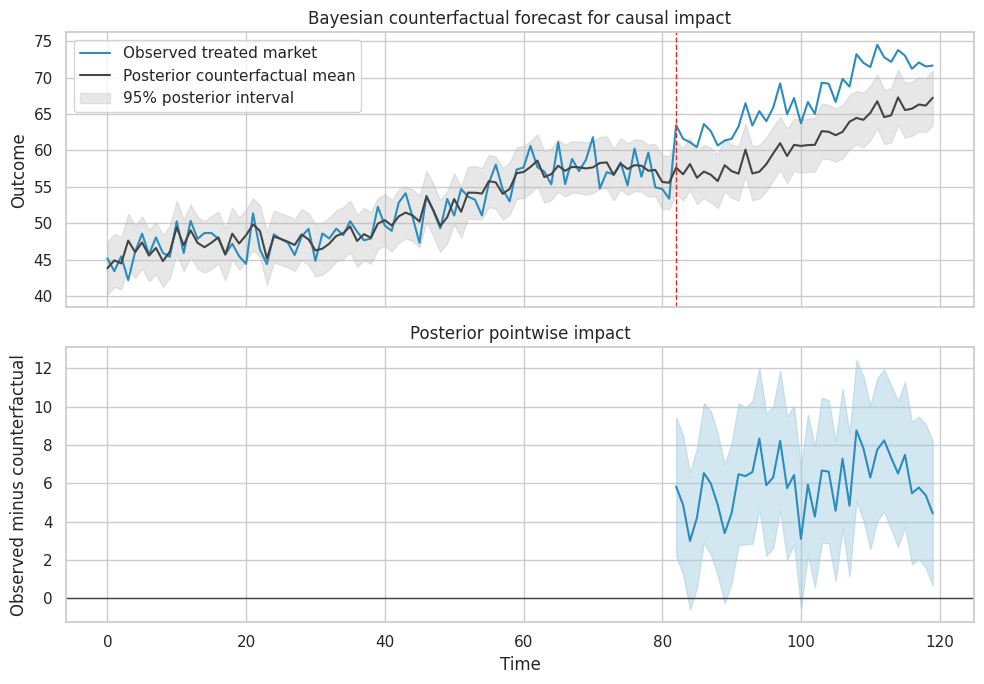

In [18]:
cf_mean = counterfactual_draws.mean(axis=0)
cf_low = np.quantile(counterfactual_draws, 0.025, axis=0)
cf_high = np.quantile(counterfactual_draws, 0.975, axis=0)

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

axes[0].plot(ts_df["time"], ts_df["treated_market"], label="Observed treated market", color="#2b8cbe")
axes[0].plot(ts_df["time"], cf_mean, label="Posterior counterfactual mean", color="#444444")
axes[0].fill_between(ts_df["time"], cf_low, cf_high, color="#bdbdbd", alpha=0.35, label="95% posterior interval")
axes[0].axvline(intervention_time, color="#de2d26", linestyle="--", linewidth=1)
axes[0].set_title("Bayesian counterfactual forecast for causal impact")
axes[0].set_ylabel("Outcome")
axes[0].legend()

impact_mean = pointwise_impact_draws.mean(axis=0)
impact_low = np.quantile(pointwise_impact_draws, 0.025, axis=0)
impact_high = np.quantile(pointwise_impact_draws, 0.975, axis=0)
axes[1].plot(post["time"], impact_mean, color="#2b8cbe", label="Pointwise impact")
axes[1].fill_between(post["time"], impact_low, impact_high, color="#9ecae1", alpha=0.45)
axes[1].axhline(0, color="#444444", linewidth=1)
axes[1].set_title("Posterior pointwise impact")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Observed minus counterfactual")

plt.tight_layout()
plt.show()


### Causal Caveat

The time-series posterior is causal only if the controls represent what would have happened to the treated market absent intervention.

The method can fail if:

- control markets are affected by the intervention,
- the treated market was already diverging before treatment,
- post-period shocks hit only the treated market,
- the intervention changes measurement,
- the pre-period relationship is unstable.


## 11. Bayesian Decision Analysis

Bayesian causal inference is naturally connected to decisions.

Suppose the product intervention from the A/B test creates value per additional conversion, but launch has implementation cost and possible downside cost.

For each posterior draw, compute profit:

$$
Profit = Users \times Lift \times ValuePerConversion - Cost
$$

Then ask:

$$
P(Profit > 0 \mid data)
$$

and expected profit:

$$
E[Profit \mid data]
$$


In [19]:
users_next_quarter = 900_000
value_per_conversion = 38
implementation_cost = 180_000

profit_draws = users_next_quarter * lift_draws * value_per_conversion - implementation_cost

decision_summary = pd.Series(
    {
        "posterior_expected_profit": profit_draws.mean(),
        "posterior_median_profit": np.median(profit_draws),
        "profit_q025": np.quantile(profit_draws, 0.025),
        "profit_q975": np.quantile(profit_draws, 0.975),
        "Pr(profit > 0)": np.mean(profit_draws > 0),
        "expected_loss_if_launch": np.mean(np.maximum(-profit_draws, 0)),
        "expected_opportunity_loss_if_do_not_launch": np.mean(np.maximum(profit_draws, 0)),
    }
)

decision_summary


posterior_expected_profit                     178,248.7127
posterior_median_profit                       178,219.1188
profit_q025                                  -252,143.2949
profit_q975                                   603,502.4290
Pr(profit > 0)                                      0.7944
expected_loss_if_launch                        25,429.2816
expected_opportunity_loss_if_do_not_launch    203,677.9943
dtype: float64

This is a checkpoint for the design and the estimate together. Priors and likelihoods are part of the decision analysis, so sensitivity should remain visible.

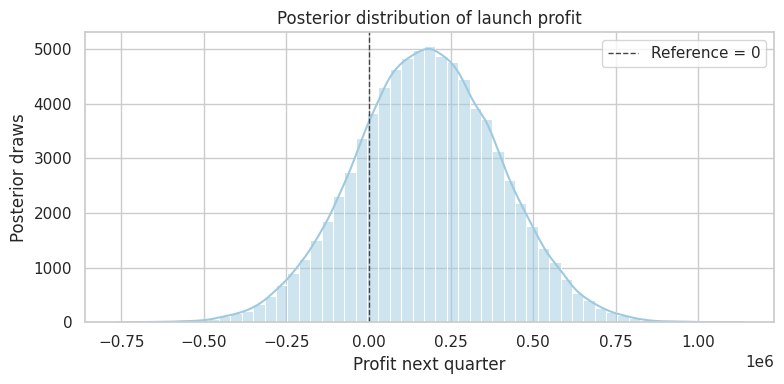

In [20]:
plot_posterior(
    profit_draws,
    title="Posterior distribution of launch profit",
    xlabel="Profit next quarter",
    reference=0,
    figsize=(8, 4),
)
plt.show()


This is where Bayesian analysis often feels very natural for business settings. We simulate the business outcome implied by the posterior causal effect directly, without translating p-values into decisions indirectly.

The launch decision can still depend on risk tolerance, reversibility, strategic value, and fairness constraints. Bayesian expected value is an input to decision-making, not the entire decision.


## 12. Bayesian Causal Workflow

A practical Bayesian causal workflow:


| step | question | artifact |
|---|---|---|
| Define causal estimand | ATE, ATT, CATE, policy value, cumulative impact, or decision utility? | Estimand statement. |
| Justify identification | Why are missing potential outcomes learnable from observed data? | Design DAG and assumptions. |
| Choose likelihood | What outcome model connects observed data to potential outcomes? | Model specification. |
| Choose priors | What prior knowledge, regularization, or skepticism is appropriate? | Prior predictive checks and sensitivity grid. |
| Compute posterior | Can we sample or approximate the posterior reliably? | Posterior draws and diagnostics. |
| Posterior predictive checks | Does the model reproduce relevant features of the data? | Predicted vs observed plots. |
| Causal sensitivity | How do unmeasured confounding, measurement error, or transport assumptions affect the result? | Bias prior or sensitivity analysis. |
| Decision analysis | What action maximizes expected utility under uncertainty? | Expected value, downside risk, and decision memo. |


## 13. Industry Decision Memo Example

Here is a concise Bayesian causal memo.


In [22]:
memo = f'''
### Bayesian Causal Decision Memo

**Decision.** Decide whether to launch a checkout intervention to all eligible users next quarter.

**Design.** The effect estimate comes from a randomized A/B test, so treatment assignment is ignorable by design.

**Estimand.** Average effect on conversion probability among users eligible for next-quarter rollout.

**Posterior result.**

- Posterior mean absolute lift: {lift_draws.mean():.4f}
- 95% credible interval: [{np.quantile(lift_draws, 0.025):.4f}, {np.quantile(lift_draws, 0.975):.4f}]
- Probability lift is positive: {np.mean(lift_draws > 0):.3f}
- Probability lift exceeds 0.5 percentage points: {np.mean(lift_draws > 0.005):.3f}

**Business value.**

- Expected next-quarter profit: ${profit_draws.mean():,.0f}
- Probability profit is positive: {np.mean(profit_draws > 0):.3f}
- 95% posterior interval for profit: [${np.quantile(profit_draws, 0.025):,.0f}, ${np.quantile(profit_draws, 0.975):,.0f}]

**Sensitivity.**

- Results should be rechecked for telemetry changes, heterogeneous effects by device type, and transport to international users.
- If implementation cost rises above the current estimate, rerun the decision calculation.

**Recommendation.**

Launch if the team accepts the posterior downside risk and monitoring is in place for conversion, refund rate, and support contacts.
'''.strip()

display(Markdown(memo))


### Bayesian Causal Decision Memo

**Decision.** Decide whether to launch a checkout intervention to all eligible users next quarter.

**Design.** The effect estimate comes from a randomized A/B test, so treatment assignment is ignorable by design.

**Estimand.** Average effect on conversion probability among users eligible for next-quarter rollout.

**Posterior result.**

- Posterior mean absolute lift: 0.0105
- 95% credible interval: [-0.0021, 0.0229]
- Probability lift is positive: 0.949
- Probability lift exceeds 0.5 percentage points: 0.806

**Business value.**

- Expected next-quarter profit: $178,249
- Probability profit is positive: 0.794
- 95% posterior interval for profit: [$-252,143, $603,502]

**Sensitivity.**

- Results should be rechecked for telemetry changes, heterogeneous effects by device type, and transport to international users.
- If implementation cost rises above the current estimate, rerun the decision calculation.

**Recommendation.**

Launch if the team accepts the posterior downside risk and monitoring is in place for conversion, refund rate, and support contacts.

## 14. Common Failure Modes

1. Treating Bayesian posterior certainty as causal identification.
2. Using a flexible model to adjust for the wrong covariates.
3. Reporting posterior probabilities without stating the prior.
4. Hiding prior sensitivity in small experiments.
5. Treating narrow posterior intervals as valid when measurement or assignment is flawed.
6. Using hierarchical shrinkage to hide real segment differences.
7. Applying causal-impact forecasting when control series are contaminated.
8. Optimizing expected value while ignoring downside risk, fairness, or reversibility.
9. Confusing posterior predictive accuracy with causal validity.
10. Forgetting that decision analysis requires costs, benefits, and constraints outside the statistical model.


## 15. Exercises

1. In the binary A/B test, replace the uniform prior with `Beta(50, 450)` for both arms. How much does the posterior lift change?
2. Change the decision threshold from 0.5 percentage points to 1 percentage point. How does the launch probability change?
3. In the continuous experiment, reduce the sample size to 200. Compare unadjusted and regression-adjusted posterior intervals.
4. In the confounding simulation, increase the effect of unobserved $U$ on treatment assignment. How does the adjusted-for-$X$ posterior move?
5. In the hierarchical segment example, double the number of tiny segments. Which estimates shrink most?
6. In the causal-impact example, add a post-period shock only to the treated market. Can the model distinguish the shock from treatment?
7. Build a decision analysis where the cost of a false launch is asymmetric and much larger than the opportunity cost of waiting.


## 16. Key Takeaways

- Bayesian causal inference combines causal identification assumptions with posterior uncertainty.
- Randomized experiments make Bayesian treatment-effect estimation especially clean.
- Posterior probabilities are useful for decision-making, but they are conditional on model and prior assumptions.
- Bayesian regression adjustment can improve precision, but it does not solve omitted-variable bias.
- Priors matter most when data are weak or decisions are close.
- Hierarchical models stabilize noisy subgroup effects through partial pooling.
- Bayesian causal-impact models are counterfactual forecasting tools; their causal validity depends on control-series assumptions.
- Decision analysis is one of the strongest practical reasons to use Bayesian causal inference in industry.


## References

Brodersen, K. H., Gallusser, F., Koehler, J., Remy, N., & Scott, S. L. (2015). Inferring causal impact using Bayesian structural time-series models. *The Annals of Applied Statistics, 9*(1), 247-274. [https://doi.org/10.1214/14-AOAS788](https://doi.org/10.1214/14-AOAS788)

Gelman, A., Carlin, J. B., Stern, H. S., Dunson, D. B., Vehtari, A., & Rubin, D. B. (2013). *Bayesian data analysis* (3rd ed.). Chapman & Hall/CRC. [https://doi.org/10.1201/b16018](https://doi.org/10.1201/b16018)

Hahn, P. R., Murray, J. S., & Carvalho, C. M. (2020). Bayesian regression tree models for causal inference: Regularization, confounding, and heterogeneous effects. *Bayesian Analysis, 15*(3), 965-1056. [https://doi.org/10.1214/19-BA1195](https://doi.org/10.1214/19-BA1195)

Hill, J. L. (2011). Bayesian nonparametric modeling for causal inference. *Journal of Computational and Graphical Statistics, 20*(1), 217-240. [https://doi.org/10.1198/jcgs.2010.08162](https://doi.org/10.1198/jcgs.2010.08162)

Imbens, G. W., & Rubin, D. B. (2015). *Causal inference for statistics, social, and biomedical sciences: An introduction*. Cambridge University Press. [https://doi.org/10.1017/CBO9781139025751](https://doi.org/10.1017/CBO9781139025751)

Rubin, D. B. (1978). Bayesian inference for causal effects: The role of randomization. *The Annals of Statistics, 6*(1), 34-58. [https://doi.org/10.1214/aos/1176344064](https://doi.org/10.1214/aos/1176344064)
